# Notebook 18. Cleaned-Cluster Moisture-Flux Quartile Analysis

This notebook performs the **within-cluster quartile test** requested after the cleaned `k = 2` subtype framework was established.

Why this notebook exists:

- `Notebook 15` settled the cleaned low-level clustering framework and favored `k = 2`
- `Notebook 16` showed what the cleaned primary clusters look like physically
- `Notebook 17` showed that the cleaned event set has coherent spatial EOF structure, especially in `z850` and `z300`
- this notebook now asks the professor's next question: **within one cleaned cluster, do events with stronger JPCZ moisture-flux support also show stronger synoptic-scale support aloft?**

What this notebook does:

- loads the cleaned cluster labels from `Notebook 15`
- restores the event-level low-level and upper-level field stacks from `Notebook 17`
- defines an objective **within-cluster tiering metric**: the JPCZ-polygon weighted mean of the cleaned `850 hPa` vertical moisture-flux proxy at event peak
- splits the target cleaned cluster into **upper** and **lower** tails by that metric (default: upper/lower quartiles)
- restores or builds the missing `300 hPa` ageostrophic wind-vector event stack for those target-cluster events
- composites the lower-tail, upper-tail, and upper-minus-lower subsets for the key fields discussed in the meeting
- saves selection tables, composite datasets, box summaries, and plot files

Default target:

- `TARGET_CLUSTER_ID = 1`
- `TAIL_FRACTION = 0.25`

Change those values in the config cell if we later want to rerun the same analysis for another cleaned cluster or for upper/lower deciles.


In [2]:
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/angelicasophyaramirez-blip/JPCZcatalogcolab.git"
BRANCH = "main"
REPO_DIR = "/content/JPCZcatalog"
FORCE_REFRESH_REPO = False
PERSIST_OUTPUTS_TO_DRIVE = True
DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/JPCZcatalog_outputs"

if PERSIST_OUTPUTS_TO_DRIVE:
    from google.colab import drive

    drive.mount("/content/drive")
    os.makedirs(DRIVE_OUTPUT_DIR, exist_ok=True)
    print("Persistent output dir:", DRIVE_OUTPUT_DIR)

os.chdir("/content")

if FORCE_REFRESH_REPO and os.path.exists(REPO_DIR):
    shutil.rmtree(REPO_DIR)
    print("Removed existing repo clone:", REPO_DIR)

if not os.path.exists(REPO_DIR):
    proc = subprocess.run(
        ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, REPO_DIR],
        text=True,
        capture_output=True,
    )
    print(proc.stdout)
    print(proc.stderr)
    if proc.returncode != 0:
        raise RuntimeError(f"git clone failed:\n{proc.stderr}")

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO_DIR}/requirements-colab.txt"],
        check=True,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", REPO_DIR],
        check=True,
    )
else:
    print("Using existing repo clone:", REPO_DIR)

os.chdir(REPO_DIR)
src_dir = os.path.join(REPO_DIR, "src")
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

print("Working directory:", os.getcwd())


Mounted at /content/drive
Persistent output dir: /content/drive/MyDrive/JPCZcatalog_outputs

Cloning into '/content/JPCZcatalog'...

Working directory: /content/JPCZcatalog


In [3]:
from pathlib import Path
import shutil

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from jpcz_catalog.analysis import add_japan_local_time_columns
from jpcz_catalog.config import (
    COASTAL_JAPAN_BOX,
    HOKKAIDO_BOX,
    HOKKAIDO_FRONT_BOX,
    JPCZ_POLYGON_VERTICES,
    OBJECTIVE_SUBTYPE_DOMAIN,
    PACIFIC_EAST_OF_JAPAN_BOX,
    PACIFIC_FRONT_BOX,
    SEA_OF_JAPAN_BOX,
    WORKING_DOMAIN,
    BoundingBox,
)
from jpcz_catalog.detect import prepare_detection_geometry
from jpcz_catalog.diagnostics import (
    compute_ageostrophic_wind_fields,
    compute_geopotential_height_field,
    load_snapshot,
)
from jpcz_catalog.era5 import open_arco_era5

CLEANED_RUN_EXPORT_DIR = Path("outputs/verification/objective_subtype_low_level_cleaned_sensitivity")
EOF_EXPORT_DIR = Path("outputs/verification/objective_subtype_eof_analysis")
QUARTILE_EXPORT_DIR = Path("outputs/verification/objective_subtype_cleaned_cluster_quartiles")
QUARTILE_EXPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR = Path("outputs/verification/objective_subtype_cleaned_cluster_quartile_plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CLEANED_CLUSTERED_EVENTS_PATH = CLEANED_RUN_EXPORT_DIR / "clustered_events_cleaned_low_level_k2_k3_k4.csv"
NOTEBOOK15_SOLUTION_SUMMARY_PATH = CLEANED_RUN_EXPORT_DIR / "cleaned_low_level_solution_summary.csv"
LOW_LEVEL_STACK_PATH = EOF_EXPORT_DIR / "cleaned_low_level_eof_event_fields.nc"
UPPER_LEVEL_STACK_PATH = EOF_EXPORT_DIR / "cleaned_upper_level_eof_event_fields.nc"

PRIMARY_CLUSTER_COLUMN = "cleaned_cluster_ward_2"
EXPLORATORY_CLUSTER_COLUMN = "cleaned_cluster_ward_3"
TARGET_CLUSTER_ID = 1
TAIL_FRACTION = 0.25
ERA5_TIME_CHUNK = 48
CHECKPOINT_EVERY_EVENTS = 10
FORCE_REBUILD_VECTOR_STACK = False
SAVE_PLOTS = True

LOW_LEVEL_COMPOSITE_DOMAIN = OBJECTIVE_SUBTYPE_DOMAIN
UPPER_LEVEL_COMPOSITE_DOMAIN = WORKING_DOMAIN
LOW_LEVEL_PLOT_DOMAIN = OBJECTIVE_SUBTYPE_DOMAIN
UPPER_LEVEL_PLOT_DOMAIN = WORKING_DOMAIN

RUSSIAN_COASTAL_EXCLUSION_BOXES = (
    BoundingBox(lon_min=130.5, lon_max=135.5, lat_min=42.0, lat_max=45.0),
    BoundingBox(lon_min=133.5, lon_max=139.5, lat_min=44.0, lat_max=47.25),
)

TARGET_METRIC_FIELD = "vertical_moisture_flux_proxy_850_peak"
TARGET_METRIC_LABEL = "JPCZ-polygon weighted mean 850 hPa moisture-flux proxy"
TARGET_METRIC_UNITS = "1e-3 Pa s^-1"
TARGET_METRIC_DIRECTION = "larger positive values = stronger moist-ascent proxy in the JPCZ polygon"

BOXES_FOR_SUMMARY = {
    "JPCZ polygon": None,
    "Coastal Japan": COASTAL_JAPAN_BOX,
    "Hokkaido": HOKKAIDO_BOX,
    "Hokkaido front": HOKKAIDO_FRONT_BOX,
    "Pacific east of Japan": PACIFIC_EAST_OF_JAPAN_BOX,
    "Pacific front": PACIFIC_FRONT_BOX,
    "Sea of Japan": SEA_OF_JAPAN_BOX,
}

LOW_LEVEL_FIELDS = [
    "vertical_moisture_flux_proxy_850_peak",
    "z850_anomaly_min_tminus12_to_tplus12",
    "divergence_925_peak",
]
UPPER_LEVEL_SCALAR_FIELDS = [
    "z300_anomaly_peak",
    "ageostrophic_divergence_300_peak",
]
UPPER_LEVEL_VECTOR_FIELDS = [
    "ageostrophic_u_300_peak",
    "ageostrophic_v_300_peak",
]

FIELD_DISPLAY_NAMES = {
    "vertical_moisture_flux_proxy_850_peak": "850 hPa vertical moisture-flux proxy at event peak (Russian coastal exclusion)",
    "z850_anomaly_min_tminus12_to_tplus12": "850 hPa z anomaly minimum over t-12/t0/t+12 (Russian coastal exclusion)",
    "divergence_925_peak": "925 hPa signed divergence at event peak (Russian coastal exclusion)",
    "z300_anomaly_peak": "300 hPa geopotential-height anomaly at event peak",
    "ageostrophic_divergence_300_peak": "300 hPa ageostrophic divergence at event peak",
    "ageostrophic_u_300_peak": "300 hPa ageostrophic zonal wind at event peak",
    "ageostrophic_v_300_peak": "300 hPa ageostrophic meridional wind at event peak",
}
SHORT_FIELD_DISPLAY_NAMES = {
    "vertical_moisture_flux_proxy_850_peak": "850 hPa moisture-flux proxy",
    "z850_anomaly_min_tminus12_to_tplus12": "850 hPa z anomaly minimum",
    "divergence_925_peak": "925 hPa signed divergence",
    "z300_anomaly_peak": "300 hPa geopotential-height anomaly",
    "ageostrophic_divergence_300_peak": "300 hPa ageostrophic divergence",
    "ageostrophic_u_300_peak": "300 hPa ageostrophic zonal wind",
    "ageostrophic_v_300_peak": "300 hPa ageostrophic meridional wind",
}
FIELD_UNITS = {
    "vertical_moisture_flux_proxy_850_peak": "1e-3 Pa s^-1",
    "z850_anomaly_min_tminus12_to_tplus12": "gpm",
    "divergence_925_peak": "1e-5 s^-1",
    "z300_anomaly_peak": "gpm",
    "ageostrophic_divergence_300_peak": "1e-5 s^-1",
    "ageostrophic_u_300_peak": "m s^-1",
    "ageostrophic_v_300_peak": "m s^-1",
}

FIELD_CMAPS = {
    "vertical_moisture_flux_proxy_850_peak": "BrBG",
    "z850_anomaly_min_tminus12_to_tplus12": "RdBu_r",
    "divergence_925_peak": "RdBu_r",
    "z300_anomaly_peak": "RdBu_r",
    "ageostrophic_divergence_300_peak": "RdBu_r",
}

TARGET_CLUSTER_SAFE = f"cluster{TARGET_CLUSTER_ID}"
VECTOR_STACK_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_ageostrophic_wind_event_fields.nc"
VECTOR_STACK_PARTIAL_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_ageostrophic_wind_event_fields_partial.nc"
TARGET_METRIC_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_target_metric_by_event.csv"
TAIL_SELECTION_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_quartile_selection.csv"
TAIL_SUMMARY_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_quartile_summary.csv"
VECTOR_STACK_SUMMARY_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_vector_stack_summary.csv"
COMPOSITE_DATASET_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_quartile_composites.nc"
SAMPLE_COUNT_SUMMARY_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_quartile_sample_counts.csv"
BOX_SUMMARY_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_quartile_box_summary.csv"
COMPOSITE_MEAN_SUMMARY_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_quartile_composite_mean_summary.csv"
PLOT_INVENTORY_PATH = QUARTILE_EXPORT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_quartile_plot_inventory.csv"


def maybe_copy_to_drive(path: Path, *, verbose: bool = True):
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return None
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if path.is_file():
        shutil.copy2(path, drive_path)
        if verbose:
            print("Copied to Drive:", drive_path)
        return drive_path
    return None



def restore_from_drive_cache(path: Path) -> bool:
    if not PERSIST_OUTPUTS_TO_DRIVE:
        return False
    drive_path = Path(DRIVE_OUTPUT_DIR) / path.name
    if not drive_path.exists():
        return False
    path.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(drive_path, path)
    print("Restored from Drive:", drive_path, "->", path)
    return True



def ordinal_word(value: int) -> str:
    lookup = {1: "first", 2: "second", 3: "third", 4: "fourth", 5: "fifth"}
    return lookup.get(value, f"{value}th")



def size_rank_descriptor(rank: int, total: int) -> str:
    if total <= 1:
        return "only subgroup"
    if rank == 1:
        return "largest subgroup"
    if rank == total:
        return "smallest subgroup"
    return f"{ordinal_word(rank)}-largest subgroup"



def build_cluster_labels_from_counts(cluster_counts: pd.Series | dict[int, int]):
    counts_dict = {int(cluster_id): int(n_events) for cluster_id, n_events in dict(cluster_counts).items()}
    ranked = sorted(counts_dict.items(), key=lambda item: (-item[1], item[0]))
    rank_lookup = {cluster_id: rank for rank, (cluster_id, _) in enumerate(ranked, start=1)}
    total = len(ranked)
    long_labels = {}
    rows = []
    for cluster_id, n_events in sorted(counts_dict.items()):
        descriptor = size_rank_descriptor(rank_lookup[cluster_id], total)
        long_labels[cluster_id] = f"Cluster {cluster_id}: n={n_events} ({descriptor})"
        rows.append(
            {
                "cluster_id": cluster_id,
                "n_events": n_events,
                "size_rank": rank_lookup[cluster_id],
                "size_descriptor": descriptor,
                "cluster_label": long_labels[cluster_id],
            }
        )
    return long_labels, pd.DataFrame(rows)



def build_russian_coastal_keep_mask(target_field: xr.DataArray) -> xr.DataArray:
    lat_vals = np.asarray(target_field.latitude.values, dtype=float)
    lon_vals = np.asarray(target_field.longitude.values, dtype=float)
    lon2d, lat2d = np.meshgrid(lon_vals, lat_vals)
    keep_mask = np.ones((len(lat_vals), len(lon_vals)), dtype=bool)
    for box in RUSSIAN_COASTAL_EXCLUSION_BOXES:
        in_box = (
            (lon2d >= box.lon_min)
            & (lon2d <= box.lon_max)
            & (lat2d >= box.lat_min)
            & (lat2d <= box.lat_max)
        )
        keep_mask &= ~in_box
    return xr.DataArray(
        keep_mask,
        coords={"latitude": target_field.latitude, "longitude": target_field.longitude},
        dims=("latitude", "longitude"),
        name="russian_coastal_keep_mask",
    )



def load_cached_dataset(path: Path):
    if not path.exists():
        return None
    with xr.open_dataset(path) as ds:
        return ds.load()



def write_checkpoint_dataset(ds: xr.Dataset, path: Path):
    ds.sortby("event_index").to_netcdf(path)
    maybe_copy_to_drive(path)



def attach_event_metadata(event_ds: xr.Dataset, row: pd.Series) -> xr.Dataset:
    event_index = int(row.name)
    event_peak = np.datetime64(pd.Timestamp(row["event_peak"]).to_datetime64())
    expanded = event_ds.expand_dims(event_index=[event_index])
    expanded = expanded.assign_coords(
        event_peak=("event_index", [event_peak]),
        cleaned_cluster_k2=("event_index", [int(row[PRIMARY_CLUSTER_COLUMN])]),
        cleaned_cluster_k3=("event_index", [int(row[EXPLORATORY_CLUSTER_COLUMN])]),
    )
    return expanded



def safe_concat(existing_ds: xr.Dataset | None, new_ds: xr.Dataset) -> xr.Dataset:
    if existing_ds is None:
        return new_ds
    return xr.concat([existing_ds, new_ds], dim="event_index").sortby("event_index")



def lat_weighted_field_mean(field: xr.DataArray, weight_field: xr.DataArray) -> xr.DataArray:
    valid = xr.apply_ufunc(np.isfinite, field)
    weighted_field = field.where(valid, 0.0) * weight_field.where(valid, 0.0)
    denominator = weight_field.where(valid, 0.0).sum(dim=("latitude", "longitude"))
    numerator = weighted_field.sum(dim=("latitude", "longitude"))
    return xr.where(denominator > 0.0, numerator / denominator, np.nan)



def lat_weighted_box_mean(field: xr.DataArray, box) -> float:
    subset = field.sel(
        longitude=slice(box.lon_min, box.lon_max),
        latitude=slice(box.lat_max, box.lat_min),
    )
    if subset.size == 0:
        return float("nan")
    lat_weights = xr.DataArray(
        np.cos(np.deg2rad(subset.latitude.values)),
        coords={"latitude": subset.latitude.values},
        dims=("latitude",),
    ).broadcast_like(subset)
    valid = xr.apply_ufunc(np.isfinite, subset)
    numerator = (subset.where(valid, 0.0) * lat_weights.where(valid, 0.0)).sum()
    denominator = lat_weights.where(valid, 0.0).sum()
    denominator_value = float(denominator.values)
    if denominator_value <= 0.0:
        return float("nan")
    return float((numerator / denominator).values)



def build_subset_labels(target_cluster_label: str, n_total: int, n_tail: int):
    return {
        "lower": f"Lower {int(TAIL_FRACTION * 100)}% of {target_cluster_label} by {TARGET_METRIC_LABEL} (n={n_tail}/{n_total})",
        "upper": f"Upper {int(TAIL_FRACTION * 100)}% of {target_cluster_label} by {TARGET_METRIC_LABEL} (n={n_tail}/{n_total})",
        "difference": f"Upper minus lower {int(TAIL_FRACTION * 100)}% difference",
    }



def compute_target_cluster_vector_fields(ds: xr.Dataset, row: pd.Series, *, geometry_upper=None):
    def strip_nonspatial_coords(field: xr.DataArray, *, keep_dims=("latitude", "longitude")) -> xr.DataArray:
        drop_coords = [coord_name for coord_name in field.coords if coord_name not in keep_dims]
        if drop_coords:
            field = field.reset_coords(names=drop_coords, drop=True)
        return field

    peak_time = pd.Timestamp(row["event_peak"])
    upper_snapshot_300 = load_snapshot(
        ds,
        peak_time,
        variables=("u_component_of_wind", "v_component_of_wind", "geopotential"),
        domain=UPPER_LEVEL_COMPOSITE_DOMAIN,
        level=300,
    )
    if geometry_upper is None:
        geometry_upper = prepare_detection_geometry(
            upper_snapshot_300.longitude,
            upper_snapshot_300.latitude,
            JPCZ_POLYGON_VERTICES,
        )
    upper_dx = geometry_upper.dx
    upper_dy = geometry_upper.dy
    z300 = strip_nonspatial_coords(compute_geopotential_height_field(upper_snapshot_300))
    ageostrophic_u_300_peak, ageostrophic_v_300_peak = compute_ageostrophic_wind_fields(
        upper_snapshot_300,
        geopotential_height=z300,
        dx=upper_dx,
        dy=upper_dy,
    )
    ageostrophic_u_300_peak = strip_nonspatial_coords(ageostrophic_u_300_peak.rename("ageostrophic_u_300_peak"))
    ageostrophic_v_300_peak = strip_nonspatial_coords(ageostrophic_v_300_peak.rename("ageostrophic_v_300_peak"))
    ageostrophic_u_300_peak.attrs["units"] = "m s^-1"
    ageostrophic_v_300_peak.attrs["units"] = "m s^-1"
    return xr.Dataset(
        {
            "ageostrophic_u_300_peak": ageostrophic_u_300_peak,
            "ageostrophic_v_300_peak": ageostrophic_v_300_peak,
        }
    ), geometry_upper



def summarize_stack_dataset(ds: xr.Dataset) -> pd.DataFrame:
    rows = []
    for field_name, field in ds.data_vars.items():
        valid_fraction = xr.apply_ufunc(np.isfinite, field).mean(dim="event_index")
        rows.append(
            {
                "field": field_name,
                "n_events": int(field.sizes["event_index"]),
                "latitude_size": int(field.sizes["latitude"]),
                "longitude_size": int(field.sizes["longitude"]),
                "mean_gridcell_valid_fraction": float(valid_fraction.mean().values),
                "min_gridcell_valid_fraction": float(valid_fraction.min().values),
                "max_gridcell_valid_fraction": float(valid_fraction.max().values),
            }
        )
    return pd.DataFrame(rows)



def mean_dataset_over_events(ds: xr.Dataset, event_indices: list[int]) -> xr.Dataset:
    subset = ds.sel(event_index=event_indices).sortby("event_index")
    return subset.mean(dim="event_index", skipna=True)



def count_dataset_over_events(ds: xr.Dataset, event_indices: list[int]) -> xr.Dataset:
    subset = ds.sel(event_index=event_indices).sortby("event_index")
    data_vars = {}
    for field_name, field in subset.data_vars.items():
        data_vars[field_name] = xr.apply_ufunc(np.isfinite, field).sum(dim="event_index").astype(np.int32)
    return xr.Dataset(data_vars)



def build_symmetric_levels(*arrays, n_levels: int = 13) -> np.ndarray:
    max_abs = 0.0
    for arr in arrays:
        values = np.asarray(arr.values if hasattr(arr, "values") else arr, dtype=float)
        if np.isfinite(values).any():
            max_abs = max(max_abs, float(np.nanmax(np.abs(values))))
    if not np.isfinite(max_abs) or max_abs == 0.0:
        max_abs = 1.0
    return np.linspace(-max_abs, max_abs, n_levels)



def add_map_features(ax, domain, *, title: str):
    ax.set_extent([domain.lon_min, domain.lon_max, domain.lat_min, domain.lat_max], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m", linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale("10m"), linewidth=0.4, edgecolor="dimgray")
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(title, fontsize=10.5)



def plot_scalar_triptych(lower_ds: xr.Dataset, upper_ds: xr.Dataset, diff_ds: xr.Dataset, field_name: str, domain, *, title_prefix: str, levels: np.ndarray | None = None, colorbar_label: str | None = None):
    lower_field = lower_ds[field_name]
    upper_field = upper_ds[field_name]
    diff_field = diff_ds[field_name]
    if levels is None:
        levels = build_symmetric_levels(lower_field, upper_field, diff_field)
    cmap = FIELD_CMAPS.get(field_name, "RdBu_r")
    panel_titles = {"lower": "Lower", "upper": "Upper", "difference": "Upper - Lower"}
    fig, axes = plt.subplots(1, 3, figsize=(15.8, 5.4), subplot_kw={"projection": ccrs.PlateCarree()})
    subset_map = [("lower", lower_field), ("upper", upper_field), ("difference", diff_field)]
    cf_last = None
    for ax, (subset_name, field) in zip(axes, subset_map):
        cf = ax.contourf(
            field.longitude,
            field.latitude,
            field,
            levels=levels,
            cmap=cmap,
            extend="both",
            transform=ccrs.PlateCarree(),
        )
        cf_last = cf
        add_map_features(ax, domain, title=panel_titles[subset_name])
    fig.suptitle(title_prefix, fontsize=13, y=0.98)
    cbar = fig.colorbar(cf_last, ax=axes, orientation="horizontal", pad=0.12, shrink=0.9, aspect=35)
    cbar.set_label(colorbar_label or f"{SHORT_FIELD_DISPLAY_NAMES[field_name]} [{FIELD_UNITS[field_name]}]")
    fig.subplots_adjust(top=0.86, bottom=0.19, wspace=0.08)
    return fig



def plot_z300_vector_triptych(lower_scalars: xr.Dataset, upper_scalars: xr.Dataset, diff_scalars: xr.Dataset, lower_vectors: xr.Dataset, upper_vectors: xr.Dataset, diff_vectors: xr.Dataset, domain, *, stride: int = 5):
    field_name = "z300_anomaly_peak"
    lower_field = lower_scalars[field_name]
    upper_field = upper_scalars[field_name]
    diff_field = diff_scalars[field_name]
    levels = build_symmetric_levels(lower_field, upper_field, diff_field)
    panel_titles = {"lower": "Lower", "upper": "Upper", "difference": "Upper - Lower"}
    fig, axes = plt.subplots(1, 3, figsize=(16.2, 5.6), subplot_kw={"projection": ccrs.PlateCarree()})
    subset_info = [
        ("lower", lower_field, lower_vectors["ageostrophic_u_300_peak"], lower_vectors["ageostrophic_v_300_peak"]),
        ("upper", upper_field, upper_vectors["ageostrophic_u_300_peak"], upper_vectors["ageostrophic_v_300_peak"]),
        ("difference", diff_field, diff_vectors["ageostrophic_u_300_peak"], diff_vectors["ageostrophic_v_300_peak"]),
    ]
    cf_last = None
    for ax, (subset_name, scalar_field, u_field, v_field) in zip(axes, subset_info):
        cf = ax.contourf(
            scalar_field.longitude,
            scalar_field.latitude,
            scalar_field,
            levels=levels,
            cmap="RdBu_r",
            extend="both",
            transform=ccrs.PlateCarree(),
        )
        cf_last = cf
        add_map_features(ax, domain, title=panel_titles[subset_name])
        ax.quiver(
            scalar_field.longitude.values[::stride],
            scalar_field.latitude.values[::stride],
            u_field.values[::stride, ::stride],
            v_field.values[::stride, ::stride],
            transform=ccrs.PlateCarree(),
            color="black",
            scale=140,
            width=0.0022,
            headwidth=3.2,
            headlength=4.0,
        )
    fig.suptitle("300 hPa geopotential-height anomaly with ageostrophic wind", fontsize=13, y=0.98)
    cbar = fig.colorbar(cf_last, ax=axes, orientation="horizontal", pad=0.12, shrink=0.9, aspect=35)
    cbar.set_label("300 hPa geopotential-height anomaly [gpm]")
    fig.subplots_adjust(top=0.86, bottom=0.19, wspace=0.08)
    return fig



def plot_target_metric_distribution(metric_df: pd.DataFrame, *, lower_threshold: float, upper_threshold: float, subset_labels: dict[str, str]):
    fig, ax = plt.subplots(figsize=(9.2, 4.8))
    ax.hist(metric_df["target_metric_value"], bins=22, color="#bdbdbd", edgecolor="white")
    ax.axvline(lower_threshold, color="#1f78b4", linestyle="--", linewidth=2, label="Lower threshold")
    ax.axvline(upper_threshold, color="#d95f02", linestyle="--", linewidth=2, label="Upper threshold")
    ax.set_title("Cluster 1 quartile tiering metric distribution")
    ax.set_xlabel(f"{TARGET_METRIC_LABEL} [{TARGET_METRIC_UNITS}]")
    ax.set_ylabel("Event count")
    ax.legend(fontsize=9, frameon=False, loc="upper left")
    fig.tight_layout()
    return fig


In [4]:
paths_to_restore = [
    CLEANED_CLUSTERED_EVENTS_PATH,
    NOTEBOOK15_SOLUTION_SUMMARY_PATH,
    LOW_LEVEL_STACK_PATH,
    UPPER_LEVEL_STACK_PATH,
]
for path in paths_to_restore:
    if not path.exists():
        restore_from_drive_cache(path)

if not CLEANED_CLUSTERED_EVENTS_PATH.exists():
    raise RuntimeError("Run Notebook 15 first so the cleaned clustered event table exists.")
if not LOW_LEVEL_STACK_PATH.exists() or not UPPER_LEVEL_STACK_PATH.exists():
    raise RuntimeError("Run Notebook 17 first so the cleaned event-level field stacks exist.")

clustered_df = pd.read_csv(CLEANED_CLUSTERED_EVENTS_PATH)
clustered_df = add_japan_local_time_columns(clustered_df)
required_columns = [PRIMARY_CLUSTER_COLUMN, EXPLORATORY_CLUSTER_COLUMN, "event_peak"]
missing_columns = [column for column in required_columns if column not in clustered_df.columns]
if missing_columns:
    raise RuntimeError(f"Missing required columns in the cleaned clustered event table: {missing_columns}")

low_level_stack_ds = load_cached_dataset(LOW_LEVEL_STACK_PATH)
upper_level_stack_ds = load_cached_dataset(UPPER_LEVEL_STACK_PATH)
if low_level_stack_ds is None or upper_level_stack_ds is None:
    raise RuntimeError("Unable to restore the Notebook 17 field stacks.")

cluster_counts = clustered_df[PRIMARY_CLUSTER_COLUMN].dropna().astype(int).value_counts().sort_index()
cluster_label_lookup, cluster_label_df = build_cluster_labels_from_counts(cluster_counts)
if TARGET_CLUSTER_ID not in cluster_label_lookup:
    raise RuntimeError(f"TARGET_CLUSTER_ID={TARGET_CLUSTER_ID} is not present in the cleaned {PRIMARY_CLUSTER_COLUMN} labels.")

target_cluster_label = cluster_label_lookup[TARGET_CLUSTER_ID]
target_cluster_df = clustered_df.loc[clustered_df[PRIMARY_CLUSTER_COLUMN].astype(int) == TARGET_CLUSTER_ID].copy()
if target_cluster_df.empty:
    raise RuntimeError(f"No events found in target cluster {TARGET_CLUSTER_ID}.")

target_event_indices = target_cluster_df.index.astype(int).tolist()
low_level_target_ds = low_level_stack_ds.sel(event_index=target_event_indices).sortby("event_index")
upper_level_target_ds = upper_level_stack_ds.sel(event_index=target_event_indices).sortby("event_index")

geometry_low = prepare_detection_geometry(
    low_level_target_ds.longitude,
    low_level_target_ds.latitude,
    JPCZ_POLYGON_VERTICES,
)
metric_da = lat_weighted_field_mean(low_level_target_ds[TARGET_METRIC_FIELD], geometry_low.weights)
metric_df = pd.DataFrame(
    {
        "event_index": low_level_target_ds["event_index"].values.astype(int),
        "event_peak": pd.to_datetime(low_level_target_ds["event_peak"].values),
        PRIMARY_CLUSTER_COLUMN: low_level_target_ds["cleaned_cluster_k2"].values.astype(int),
        EXPLORATORY_CLUSTER_COLUMN: low_level_target_ds["cleaned_cluster_k3"].values.astype(int),
        "target_metric_value": metric_da.values.astype(float),
    }
)
metric_df = metric_df.merge(
    target_cluster_df[["event_peak_jst", "duration_hours"]],
    left_on="event_index",
    right_index=True,
    how="left",
)
metric_df = metric_df.sort_values("target_metric_value", ascending=False).reset_index(drop=True)
finite_metric_df = metric_df.loc[np.isfinite(metric_df["target_metric_value"])].copy()
if finite_metric_df.empty:
    raise RuntimeError("The target-cluster tiering metric is all missing values.")

tail_count = max(1, int(np.floor(len(finite_metric_df) * TAIL_FRACTION)))
if 2 * tail_count > len(finite_metric_df):
    raise RuntimeError("Not enough finite target-cluster events to define disjoint lower and upper tails.")

upper_tail_df = finite_metric_df.head(tail_count).copy()
lower_tail_df = finite_metric_df.tail(tail_count).copy()
upper_event_indices = upper_tail_df["event_index"].astype(int).tolist()
lower_event_indices = lower_tail_df["event_index"].astype(int).tolist()
upper_threshold = float(upper_tail_df["target_metric_value"].min())
lower_threshold = float(lower_tail_df["target_metric_value"].max())
subset_labels = build_subset_labels(target_cluster_label, len(finite_metric_df), tail_count)

selection_df = finite_metric_df.copy()
selection_df["quartile_subset"] = "middle"
selection_df.loc[selection_df["event_index"].isin(upper_event_indices), "quartile_subset"] = "upper"
selection_df.loc[selection_df["event_index"].isin(lower_event_indices), "quartile_subset"] = "lower"

summary_df = pd.DataFrame(
    [
        {"metric": "target_cluster_id", "value": TARGET_CLUSTER_ID},
        {"metric": "target_cluster_label", "value": target_cluster_label},
        {"metric": "target_cluster_event_count", "value": len(target_cluster_df)},
        {"metric": "finite_metric_event_count", "value": len(finite_metric_df)},
        {"metric": "tail_fraction", "value": TAIL_FRACTION},
        {"metric": "tail_count", "value": tail_count},
        {"metric": "lower_tail_max_value", "value": lower_threshold},
        {"metric": "upper_tail_min_value", "value": upper_threshold},
        {"metric": "target_metric_label", "value": TARGET_METRIC_LABEL},
        {"metric": "target_metric_direction", "value": TARGET_METRIC_DIRECTION},
    ]
)

metric_df.to_csv(TARGET_METRIC_PATH, index=False)
selection_df.to_csv(TAIL_SELECTION_PATH, index=False)
summary_df.to_csv(TAIL_SUMMARY_PATH, index=False)
maybe_copy_to_drive(TARGET_METRIC_PATH)
maybe_copy_to_drive(TAIL_SELECTION_PATH)
maybe_copy_to_drive(TAIL_SUMMARY_PATH)

print("Cleaned cluster labels available for the quartile analysis")
display(cluster_label_df)
print("\nQuartile target summary")
display(summary_df)
print("\nTop 10 target-cluster events by the quartile tiering metric")
display(upper_tail_df.head(10))
print("\nBottom 10 target-cluster events by the quartile tiering metric")
display(lower_tail_df.tail(10))


Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/clustered_events_cleaned_low_level_k2_k3_k4.csv -> outputs/verification/objective_subtype_low_level_cleaned_sensitivity/clustered_events_cleaned_low_level_k2_k3_k4.csv
Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_low_level_solution_summary.csv -> outputs/verification/objective_subtype_low_level_cleaned_sensitivity/cleaned_low_level_solution_summary.csv
Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_low_level_eof_event_fields.nc -> outputs/verification/objective_subtype_eof_analysis/cleaned_low_level_eof_event_fields.nc
Restored from Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_upper_level_eof_event_fields.nc -> outputs/verification/objective_subtype_eof_analysis/cleaned_upper_level_eof_event_fields.nc
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_target_metric_by_event.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_o

,cluster_id,n_events,size_rank,size_descriptor,cluster_label
0,1,180,1,largest subgroup,Cluster 1: n=180 (largest subgroup)
1,2,21,2,smallest subgroup,Cluster 2: n=21 (smallest subgroup)



Quartile target summary


,metric,value
0,target_cluster_id,1
1,target_cluster_label,Cluster 1: n=180 (largest subgroup)
2,target_cluster_event_count,180
3,finite_metric_event_count,180
4,tail_fraction,0.25
5,tail_count,45
6,lower_tail_max_value,0.458112
7,upper_tail_min_value,0.935503
8,target_metric_label,JPCZ-polygon weighted mean 850 hPa moisture-fl...
9,target_metric_direction,larger positive values = stronger moist-ascent...



Top 10 target-cluster events by the quartile tiering metric


,event_index,event_peak,cleaned_cluster_ward_2,cleaned_cluster_ward_3,target_metric_value,event_peak_jst,duration_hours
0,163,2015-11-07 21:00:00,1,3,4.499557,2015-11-08 06:00:00,17
1,101,2009-12-11 03:00:00,1,3,2.554471,2009-12-11 12:00:00,8
2,0,2000-01-05 23:00:00,1,3,2.420175,2000-01-06 08:00:00,2
3,164,2015-11-14 01:00:00,1,3,2.387065,2015-11-14 10:00:00,11
4,166,2015-11-25 21:00:00,1,3,2.115860,2015-11-26 06:00:00,18
5,94,2008-12-04 20:00:00,1,3,2.008233,2008-12-05 05:00:00,5
6,147,2013-11-25 02:00:00,1,3,1.991662,2013-11-25 11:00:00,11
7,95,2008-12-21 06:00:00,1,1,1.836036,2008-12-21 15:00:00,30
8,200,2018-12-06 04:00:00,1,1,1.784867,2018-12-06 13:00:00,14
9,130,2012-11-11 10:00:00,1,3,1.724254,2012-11-11 19:00:00,8



Bottom 10 target-cluster events by the quartile tiering metric


,event_index,event_peak,cleaned_cluster_ward_2,cleaned_cluster_ward_3,target_metric_value,event_peak_jst,duration_hours
170,16,2001-02-13 21:00:00,1,1,0.272905,2001-02-14 06:00:00,4
171,13,2001-01-14 16:00:00,1,3,0.266973,2001-01-15 01:00:00,10
172,135,2012-12-08 23:00:00,1,1,0.262900,2012-12-09 08:00:00,1
173,129,2012-02-17 12:00:00,1,1,0.260804,2012-02-17 21:00:00,10
174,5,2000-02-17 09:00:00,1,1,0.259961,2000-02-17 18:00:00,3
175,143,2013-02-07 04:00:00,1,3,0.253168,2013-02-07 13:00:00,11
176,158,2015-01-06 04:00:00,1,3,0.229553,2015-01-06 13:00:00,9
177,141,2013-01-24 18:00:00,1,3,0.161312,2013-01-25 03:00:00,3
178,197,2018-02-10 23:00:00,1,1,0.131138,2018-02-11 08:00:00,7
179,40,2003-01-29 03:00:00,1,1,0.114427,2003-01-29 12:00:00,27


In [5]:
required_globals = [
    "clustered_df",
    "target_cluster_df",
    "target_event_indices",
    "restore_from_drive_cache",
    "maybe_copy_to_drive",
    "compute_target_cluster_vector_fields",
    "attach_event_metadata",
    "safe_concat",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the setup/import cell, the Notebook 18 config/helper cell, and the cleaned-cluster quartile context cell before the vector-stack build cell. "
        f"Missing globals: {missing_globals}"
    )

for path in [VECTOR_STACK_PATH, VECTOR_STACK_PARTIAL_PATH, VECTOR_STACK_SUMMARY_PATH]:
    if not path.exists():
        restore_from_drive_cache(path)

vector_stack_ds = None
processed_event_indices = []
resume_source = "fresh rebuild"

if VECTOR_STACK_PATH.exists() and not FORCE_REBUILD_VECTOR_STACK:
    vector_stack_ds = load_cached_dataset(VECTOR_STACK_PATH)
    if vector_stack_ds is not None:
        cached_indices = [int(value) for value in vector_stack_ds["event_index"].values.tolist()]
        if cached_indices == sorted(target_event_indices):
            processed_event_indices = cached_indices
            resume_source = "restored cached final target-cluster vector stack"
        else:
            vector_stack_ds = None
elif VECTOR_STACK_PARTIAL_PATH.exists() and not FORCE_REBUILD_VECTOR_STACK:
    vector_stack_ds = load_cached_dataset(VECTOR_STACK_PARTIAL_PATH)
    if vector_stack_ds is not None:
        cached_indices = [int(value) for value in vector_stack_ds["event_index"].values.tolist()]
        if set(cached_indices).issubset(set(target_event_indices)):
            processed_event_indices = sorted(cached_indices)
            resume_source = "restored partial target-cluster vector stack"
        else:
            vector_stack_ds = None

print(f"Target-cluster vector-stack source before this run: {resume_source}")
print(f"Target-cluster vector-stack progress before this run: {len(processed_event_indices)}/{len(target_event_indices)} events")

remaining_rows = target_cluster_df.loc[~target_cluster_df.index.isin(processed_event_indices)].copy()
if not remaining_rows.empty:
    era5_runtime_ds = open_arco_era5(chunks={"time": ERA5_TIME_CHUNK})
    geometry_upper = None
    if vector_stack_ds is not None and len(processed_event_indices) > 0:
        sample_upper = vector_stack_ds["ageostrophic_u_300_peak"].isel(event_index=0)
        geometry_upper = prepare_detection_geometry(sample_upper.longitude, sample_upper.latitude, JPCZ_POLYGON_VERTICES)

    for event_counter, (_, row) in enumerate(remaining_rows.iterrows(), start=1):
        event_vector_ds, geometry_upper = compute_target_cluster_vector_fields(
            era5_runtime_ds,
            row,
            geometry_upper=geometry_upper,
        )
        event_vector_ds = attach_event_metadata(event_vector_ds, row)
        vector_stack_ds = safe_concat(vector_stack_ds, event_vector_ds)
        processed_total = len(vector_stack_ds["event_index"]) if vector_stack_ds is not None else 0
        if processed_total % CHECKPOINT_EVERY_EVENTS == 0 or processed_total == len(target_event_indices):
            write_checkpoint_dataset(vector_stack_ds, VECTOR_STACK_PARTIAL_PATH)
            print(f"Checkpointed target-cluster vector stack at {processed_total}/{len(target_event_indices)} events")

if vector_stack_ds is None:
    raise RuntimeError("Unable to build or restore the target-cluster ageostrophic-wind vector stack.")

vector_stack_ds = vector_stack_ds.sortby("event_index")
expected_indices = sorted(target_event_indices)
actual_indices = [int(value) for value in vector_stack_ds["event_index"].values.tolist()]
if actual_indices != expected_indices:
    raise RuntimeError(
        "The restored/built target-cluster vector stack does not match the target-cluster event index set. "
        f"Expected {len(expected_indices)} events, got {len(actual_indices)} events."
    )

write_checkpoint_dataset(vector_stack_ds, VECTOR_STACK_PATH)
stack_summary_df = summarize_stack_dataset(vector_stack_ds)
stack_summary_df.to_csv(VECTOR_STACK_SUMMARY_PATH, index=False)
maybe_copy_to_drive(VECTOR_STACK_SUMMARY_PATH)
print("Saved final target-cluster ageostrophic-wind vector stack")
print("\nTarget-cluster vector-stack summary")
display(stack_summary_df)


Target-cluster vector-stack source before this run: fresh rebuild
Target-cluster vector-stack progress before this run: 0/180 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_ageostrophic_wind_event_fields_partial.nc
Checkpointed target-cluster vector stack at 10/180 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_ageostrophic_wind_event_fields_partial.nc
Checkpointed target-cluster vector stack at 20/180 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_ageostrophic_wind_event_fields_partial.nc
Checkpointed target-cluster vector stack at 30/180 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_ageostrophic_wind_event_fields_partial.nc
Checkpointed target-cluster vector stack at 40/180 events
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_ageostrophic_wind_event_fields_partial.nc
Checkpointed target-clust

,field,n_events,latitude_size,longitude_size,mean_gridcell_valid_fraction,min_gridcell_valid_fraction,max_gridcell_valid_fraction
0,ageostrophic_u_300_peak,180,81,121,1.0,1.0,1.0
1,ageostrophic_v_300_peak,180,81,121,1.0,1.0,1.0


In [6]:
required_globals = [
    "low_level_target_ds",
    "upper_level_target_ds",
    "vector_stack_ds",
    "upper_event_indices",
    "lower_event_indices",
    "subset_labels",
    "geometry_low",
    "lat_weighted_box_mean",
    "lat_weighted_field_mean",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 18 vector-stack build cell before the quartile composite-analysis cell. "
        f"Missing globals: {missing_globals}"
    )

low_level_lower_ds = mean_dataset_over_events(low_level_target_ds[LOW_LEVEL_FIELDS], lower_event_indices)
low_level_upper_ds = mean_dataset_over_events(low_level_target_ds[LOW_LEVEL_FIELDS], upper_event_indices)
low_level_diff_ds = low_level_upper_ds - low_level_lower_ds

upper_scalar_lower_ds = mean_dataset_over_events(upper_level_target_ds[UPPER_LEVEL_SCALAR_FIELDS], lower_event_indices)
upper_scalar_upper_ds = mean_dataset_over_events(upper_level_target_ds[UPPER_LEVEL_SCALAR_FIELDS], upper_event_indices)
upper_scalar_diff_ds = upper_scalar_upper_ds - upper_scalar_lower_ds

vector_lower_ds = mean_dataset_over_events(vector_stack_ds[UPPER_LEVEL_VECTOR_FIELDS], lower_event_indices)
vector_upper_ds = mean_dataset_over_events(vector_stack_ds[UPPER_LEVEL_VECTOR_FIELDS], upper_event_indices)
vector_diff_ds = vector_upper_ds - vector_lower_ds

low_level_lower_counts_ds = count_dataset_over_events(low_level_target_ds[LOW_LEVEL_FIELDS], lower_event_indices)
low_level_upper_counts_ds = count_dataset_over_events(low_level_target_ds[LOW_LEVEL_FIELDS], upper_event_indices)
upper_scalar_lower_counts_ds = count_dataset_over_events(upper_level_target_ds[UPPER_LEVEL_SCALAR_FIELDS], lower_event_indices)
upper_scalar_upper_counts_ds = count_dataset_over_events(upper_level_target_ds[UPPER_LEVEL_SCALAR_FIELDS], upper_event_indices)

low_level_composites_ds = xr.concat(
    [
        low_level_lower_ds.expand_dims(subset=["lower"]),
        low_level_upper_ds.expand_dims(subset=["upper"]),
        low_level_diff_ds.expand_dims(subset=["difference"]),
    ],
    dim="subset",
)
upper_scalar_composites_ds = xr.concat(
    [
        upper_scalar_lower_ds.expand_dims(subset=["lower"]),
        upper_scalar_upper_ds.expand_dims(subset=["upper"]),
        upper_scalar_diff_ds.expand_dims(subset=["difference"]),
    ],
    dim="subset",
)
vector_composites_ds = xr.concat(
    [
        vector_lower_ds.expand_dims(subset=["lower"]),
        vector_upper_ds.expand_dims(subset=["upper"]),
        vector_diff_ds.expand_dims(subset=["difference"]),
    ],
    dim="subset",
)
quartile_composites_ds = xr.merge(
    [low_level_composites_ds, upper_scalar_composites_ds, vector_composites_ds],
    compat="override",
    join="outer",
)
quartile_composites_ds.to_netcdf(COMPOSITE_DATASET_PATH)
maybe_copy_to_drive(COMPOSITE_DATASET_PATH)

sample_count_rows = []
for subset_name, count_ds, n_events in [
    ("lower", low_level_lower_counts_ds, len(lower_event_indices)),
    ("upper", low_level_upper_counts_ds, len(upper_event_indices)),
    ("lower", upper_scalar_lower_counts_ds, len(lower_event_indices)),
    ("upper", upper_scalar_upper_counts_ds, len(upper_event_indices)),
]:
    for field_name in count_ds.data_vars:
        counts = count_ds[field_name]
        sample_count_rows.append(
            {
                "subset": subset_name,
                "subset_label": subset_labels[subset_name],
                "field": field_name,
                "field_label": FIELD_DISPLAY_NAMES[field_name],
                "units": FIELD_UNITS[field_name],
                "n_events_in_subset": n_events,
                "min_gridcell_count": int(np.nanmin(counts.values)),
                "median_gridcell_count": float(np.nanmedian(counts.values)),
                "max_gridcell_count": int(np.nanmax(counts.values)),
            }
        )
sample_count_summary_df = pd.DataFrame(sample_count_rows)
sample_count_summary_df.to_csv(SAMPLE_COUNT_SUMMARY_PATH, index=False)
maybe_copy_to_drive(SAMPLE_COUNT_SUMMARY_PATH)

box_summary_rows = []
polygon_weight_field = geometry_low.weights
for subset_name, low_ds, upper_ds in [
    ("lower", low_level_lower_ds, upper_scalar_lower_ds),
    ("upper", low_level_upper_ds, upper_scalar_upper_ds),
    ("difference", low_level_diff_ds, upper_scalar_diff_ds),
]:
    for field_name in LOW_LEVEL_FIELDS + UPPER_LEVEL_SCALAR_FIELDS:
        source_ds = low_ds if field_name in low_ds.data_vars else upper_ds
        field = source_ds[field_name]
        for box_name, box in BOXES_FOR_SUMMARY.items():
            if box_name == "JPCZ polygon":
                if field_name in LOW_LEVEL_FIELDS:
                    box_mean = float(lat_weighted_field_mean(field, polygon_weight_field).values)
                else:
                    geometry_upper = prepare_detection_geometry(field.longitude, field.latitude, JPCZ_POLYGON_VERTICES)
                    box_mean = float(lat_weighted_field_mean(field, geometry_upper.weights).values)
            else:
                box_mean = lat_weighted_box_mean(field, box)
            box_summary_rows.append(
                {
                    "subset": subset_name,
                    "subset_label": subset_labels.get(subset_name, subset_name),
                    "field": field_name,
                    "field_label": FIELD_DISPLAY_NAMES[field_name],
                    "box_name": box_name,
                    "weighted_mean": box_mean,
                }
            )
box_summary_df = pd.DataFrame(box_summary_rows)
box_summary_df.to_csv(BOX_SUMMARY_PATH, index=False)
maybe_copy_to_drive(BOX_SUMMARY_PATH)

composite_mean_rows = []
for subset_name, low_ds, upper_ds, n_events in [
    ("lower", low_level_lower_ds, upper_scalar_lower_ds, len(lower_event_indices)),
    ("upper", low_level_upper_ds, upper_scalar_upper_ds, len(upper_event_indices)),
    ("difference", low_level_diff_ds, upper_scalar_diff_ds, np.nan),
]:
    merged = xr.merge([low_ds, upper_ds], compat="override", join="outer")
    for field_name in merged.data_vars:
        composite_mean_rows.append(
            {
                "subset": subset_name,
                "subset_label": subset_labels.get(subset_name, subset_name),
                "field": field_name,
                "field_label": FIELD_DISPLAY_NAMES[field_name],
                "units": FIELD_UNITS[field_name],
                "n_events": n_events,
                "full_domain_mean": float(np.nanmean(merged[field_name].values)),
            }
        )
composite_mean_summary_df = pd.DataFrame(composite_mean_rows)
composite_mean_summary_df.to_csv(COMPOSITE_MEAN_SUMMARY_PATH, index=False)
maybe_copy_to_drive(COMPOSITE_MEAN_SUMMARY_PATH)

print("Quartile subgroup sample-count summary")
display(sample_count_summary_df)
print("\nQuartile subgroup box-mean summary")
display(box_summary_df)
print("\nQuartile subgroup full-domain mean summary")
display(composite_mean_summary_df)


/tmp/ipykernel_32643/3670950853.py:60: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  quartile_composites_ds = xr.merge(
/tmp/ipykernel_32643/3670950853.py:60: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  quartile_composites_ds = xr.merge(


Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_quartile_composites.nc
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_quartile_sample_counts.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_quartile_box_summary.csv
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_quartile_composite_mean_summary.csv
Quartile subgroup sample-count summary


/tmp/ipykernel_32643/3670950853.py:132: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  merged = xr.merge([low_ds, upper_ds])
/tmp/ipykernel_32643/3670950853.py:132: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  merged = xr.merge([low_ds, upper_ds])


,subset,subset_label,field,field_label,units,n_events_in_subset,min_gridcell_count,median_gridcell_count,max_gridcell_count
0,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,1e-3 Pa s^-1,45,0,45.0,45
1,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,45,0,45.0,45
2,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,45,0,45.0,45
3,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,1e-3 Pa s^-1,45,0,45.0,45
4,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,45,0,45.0,45
5,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,45,0,45.0,45
6,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,gpm,45,45,45.0,45
7,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,1e-5 s^-1,45,45,45.0,45
8,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,gpm,45,45,45.0,45
9,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,1e-5 s^-1,45,45,45.0,45



Quartile subgroup box-mean summary


,subset,subset_label,field,field_label,box_name,weighted_mean
0,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,JPCZ polygon,0.333778
1,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,Coastal Japan,0.476137
2,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,Hokkaido,0.434995
3,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,Hokkaido front,0.389854
4,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,Pacific east of Japan,0.677358
...,...,...,...,...,...,...
100,difference,Upper minus lower 25% difference,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,Hokkaido,-0.612000
101,difference,Upper minus lower 25% difference,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,Hokkaido front,-0.442114
102,difference,Upper minus lower 25% difference,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,Pacific east of Japan,-0.389073
103,difference,Upper minus lower 25% difference,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,Pacific front,-0.389073



Quartile subgroup full-domain mean summary


,subset,subset_label,field,field_label,units,n_events,full_domain_mean
0,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,1e-3 Pa s^-1,45.0,0.400622
1,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,45.0,-86.168060
2,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,45.0,-0.340333
3,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,gpm,45.0,-116.327873
4,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,1e-5 s^-1,45.0,0.077086
5,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,1e-3 Pa s^-1,45.0,0.423085
6,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,45.0,-33.965775
7,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,45.0,-0.218038
8,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,gpm,45.0,-16.444750
9,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,1e-5 s^-1,45.0,0.153370


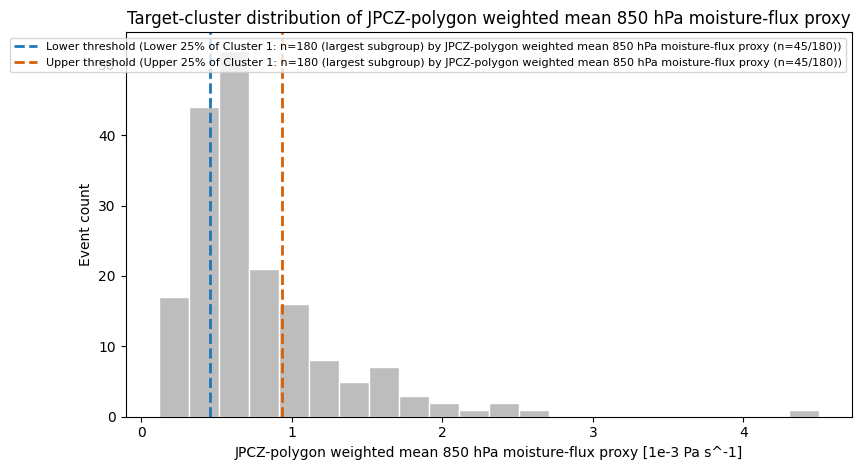

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_quartile_metric_distribution.png


/tmp/ipykernel_32643/175570766.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


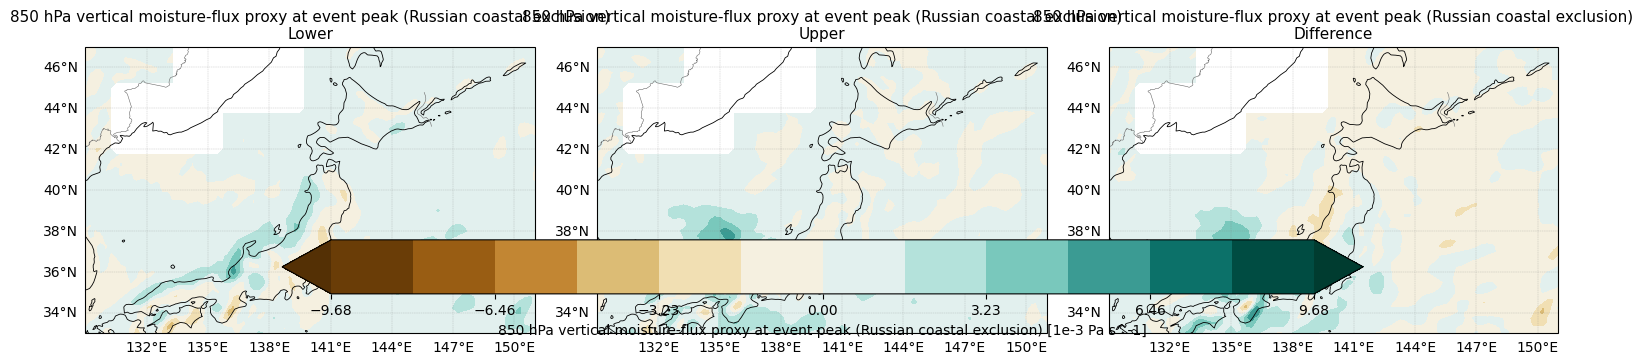

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_vertical_moisture_flux_proxy_850_peak_quartile_triptych.png


/tmp/ipykernel_32643/175570766.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


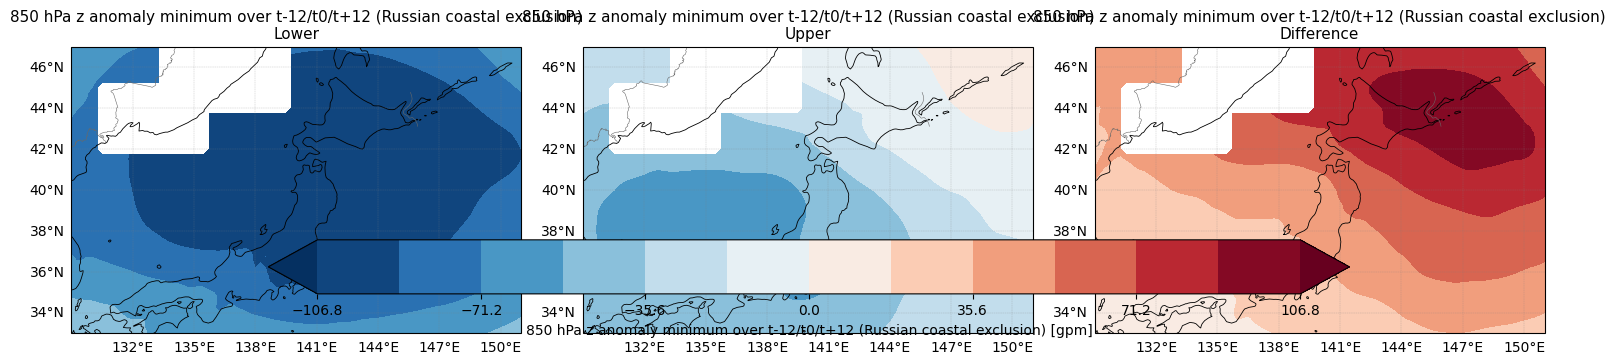

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_z850_anomaly_min_tminus12_to_tplus12_quartile_triptych.png


/tmp/ipykernel_32643/175570766.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


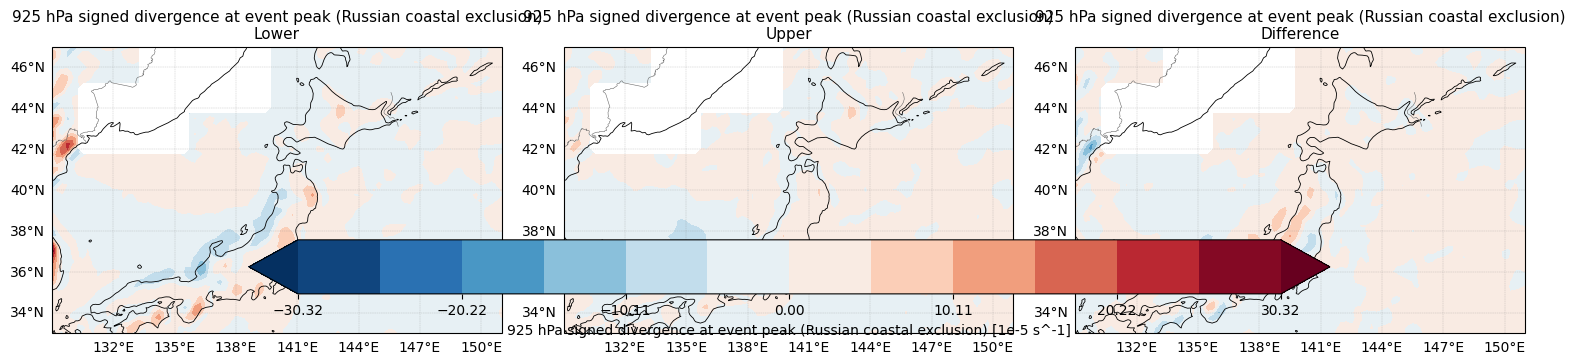

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_divergence_925_peak_quartile_triptych.png


/tmp/ipykernel_32643/175570766.py:419: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


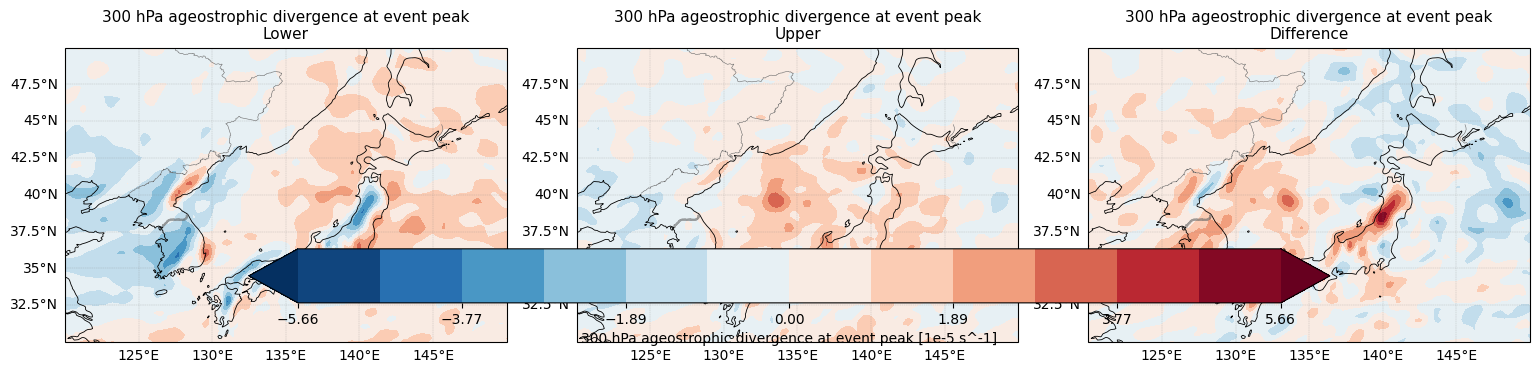

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_ageostrophic_divergence_300_peak_quartile_triptych.png


/tmp/ipykernel_32643/175570766.py:463: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


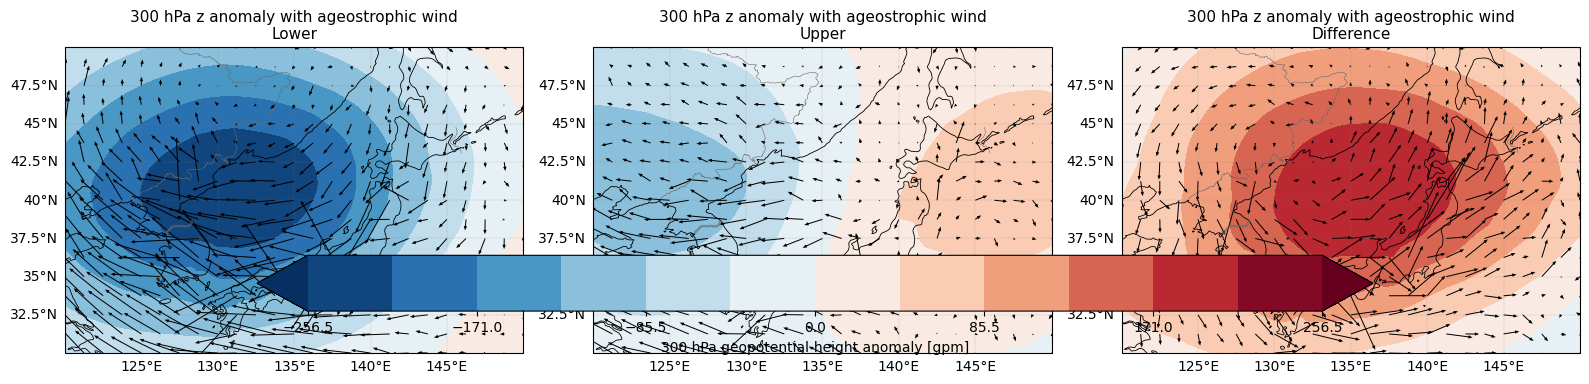

Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_z300_ageostrophic_vector_quartile_triptych.png
Copied to Drive: /content/drive/MyDrive/JPCZcatalog_outputs/cleaned_k2_cluster1_quartile_plot_inventory.csv
Saved quartile-analysis plots


,plot_kind,field,local_path,drive_path
0,histogram,vertical_moisture_flux_proxy_850_peak,outputs/verification/objective_subtype_cleaned...,/content/drive/MyDrive/JPCZcatalog_outputs/cle...
1,scalar_triptych,vertical_moisture_flux_proxy_850_peak,outputs/verification/objective_subtype_cleaned...,/content/drive/MyDrive/JPCZcatalog_outputs/cle...
2,scalar_triptych,z850_anomaly_min_tminus12_to_tplus12,outputs/verification/objective_subtype_cleaned...,/content/drive/MyDrive/JPCZcatalog_outputs/cle...
3,scalar_triptych,divergence_925_peak,outputs/verification/objective_subtype_cleaned...,/content/drive/MyDrive/JPCZcatalog_outputs/cle...
4,scalar_triptych,ageostrophic_divergence_300_peak,outputs/verification/objective_subtype_cleaned...,/content/drive/MyDrive/JPCZcatalog_outputs/cle...
5,vector_triptych,z300_anomaly_peak_with_ageostrophic_vectors,outputs/verification/objective_subtype_cleaned...,/content/drive/MyDrive/JPCZcatalog_outputs/cle...


In [7]:
required_globals = [
    "selection_df",
    "subset_labels",
    "low_level_lower_ds",
    "low_level_upper_ds",
    "low_level_diff_ds",
    "upper_scalar_lower_ds",
    "upper_scalar_upper_ds",
    "upper_scalar_diff_ds",
    "vector_lower_ds",
    "vector_upper_ds",
    "vector_diff_ds",
    "plot_target_metric_distribution",
    "plot_scalar_triptych",
    "plot_z300_vector_triptych",
    "maybe_copy_to_drive",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 18 quartile composite-analysis cell before the plotting cell. "
        f"Missing globals: {missing_globals}"
    )

plot_inventory_rows = []

fig_metric = plot_target_metric_distribution(
    selection_df,
    lower_threshold=lower_threshold,
    upper_threshold=upper_threshold,
    subset_labels=subset_labels,
)
metric_plot_path = PLOT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_quartile_metric_distribution.png"
fig_metric.savefig(metric_plot_path, dpi=160, bbox_inches="tight")
plt.show()
maybe_copy_to_drive(metric_plot_path)
plot_inventory_rows.append({"plot_kind": "histogram", "field": TARGET_METRIC_FIELD, "local_path": str(metric_plot_path), "drive_path": str(Path(DRIVE_OUTPUT_DIR) / metric_plot_path.name)})

for field_name in LOW_LEVEL_FIELDS:
    fig = plot_scalar_triptych(
        low_level_lower_ds,
        low_level_upper_ds,
        low_level_diff_ds,
        field_name,
        LOW_LEVEL_PLOT_DOMAIN,
        title_prefix=FIELD_DISPLAY_NAMES[field_name],
    )
    plot_path = PLOT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_{field_name}_quartile_triptych.png"
    fig.savefig(plot_path, dpi=160, bbox_inches="tight")
    plt.show()
    maybe_copy_to_drive(plot_path)
    plot_inventory_rows.append({"plot_kind": "scalar_triptych", "field": field_name, "local_path": str(plot_path), "drive_path": str(Path(DRIVE_OUTPUT_DIR) / plot_path.name)})

for field_name in ["ageostrophic_divergence_300_peak"]:
    fig = plot_scalar_triptych(
        upper_scalar_lower_ds,
        upper_scalar_upper_ds,
        upper_scalar_diff_ds,
        field_name,
        UPPER_LEVEL_PLOT_DOMAIN,
        title_prefix=FIELD_DISPLAY_NAMES[field_name],
    )
    plot_path = PLOT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_{field_name}_quartile_triptych.png"
    fig.savefig(plot_path, dpi=160, bbox_inches="tight")
    plt.show()
    maybe_copy_to_drive(plot_path)
    plot_inventory_rows.append({"plot_kind": "scalar_triptych", "field": field_name, "local_path": str(plot_path), "drive_path": str(Path(DRIVE_OUTPUT_DIR) / plot_path.name)})

fig_z300_vectors = plot_z300_vector_triptych(
    upper_scalar_lower_ds,
    upper_scalar_upper_ds,
    upper_scalar_diff_ds,
    vector_lower_ds,
    vector_upper_ds,
    vector_diff_ds,
    UPPER_LEVEL_PLOT_DOMAIN,
)
z300_vector_plot_path = PLOT_DIR / f"cleaned_k2_{TARGET_CLUSTER_SAFE}_z300_ageostrophic_vector_quartile_triptych.png"
fig_z300_vectors.savefig(z300_vector_plot_path, dpi=160, bbox_inches="tight")
plt.show()
maybe_copy_to_drive(z300_vector_plot_path)
plot_inventory_rows.append({"plot_kind": "vector_triptych", "field": "z300_anomaly_peak_with_ageostrophic_vectors", "local_path": str(z300_vector_plot_path), "drive_path": str(Path(DRIVE_OUTPUT_DIR) / z300_vector_plot_path.name)})

plot_inventory_df = pd.DataFrame(plot_inventory_rows)
plot_inventory_df.to_csv(PLOT_INVENTORY_PATH, index=False)
maybe_copy_to_drive(PLOT_INVENTORY_PATH)
print("Saved quartile-analysis plots")
display(plot_inventory_df)


In [8]:
required_globals = [
    "summary_df",
    "sample_count_summary_df",
    "box_summary_df",
    "composite_mean_summary_df",
]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Run the Notebook 18 plotting cell before the quartile-summary cell. "
        f"Missing globals: {missing_globals}"
    )

key_box_summary_df = box_summary_df.loc[
    box_summary_df["box_name"].isin(["JPCZ polygon", "Hokkaido", "Pacific east of Japan", "Sea of Japan"])
].copy()
key_box_summary_df["weighted_mean"] = key_box_summary_df["weighted_mean"].round(3)
composite_mean_summary_df["full_domain_mean"] = composite_mean_summary_df["full_domain_mean"].round(3)

print("Notebook 18 quartile-analysis summary")
display(summary_df)
print("\nKey box means for the lower, upper, and upper-minus-lower subsets")
display(key_box_summary_df)
print("\nFull-domain means for the lower, upper, and upper-minus-lower quartile composites")
display(composite_mean_summary_df)
print("\nNotebook 18 now does the following:")
print("- tiers one cleaned cluster by the JPCZ-polygon 850 hPa moisture-flux proxy")
print("- defines upper and lower tails objectively using the requested quartile split")
print("- compares z850, z300, 300 hPa ageostrophic divergence, 300 hPa ageostrophic wind vectors, and the 850 hPa moisture-flux proxy between those tails")
print("- saves selection tables, subgroup composites, box summaries, and plot files for the next interpretation step")


Notebook 18 quartile-analysis summary


,metric,value
0,target_cluster_id,1
1,target_cluster_label,Cluster 1: n=180 (largest subgroup)
2,target_cluster_event_count,180
3,finite_metric_event_count,180
4,tail_fraction,0.25
5,tail_count,45
6,lower_tail_max_value,0.458112
7,upper_tail_min_value,0.935503
8,target_metric_label,JPCZ-polygon weighted mean 850 hPa moisture-fl...
9,target_metric_direction,larger positive values = stronger moist-ascent...



Key box means for the lower, upper, and upper-minus-lower subsets


,subset,subset_label,field,field_label,box_name,weighted_mean
0,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,JPCZ polygon,0.334
2,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,Hokkaido,0.435
4,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,Pacific east of Japan,0.677
6,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,Sea of Japan,0.360
7,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,JPCZ polygon,-84.513
9,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,Hokkaido,-99.891
11,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,Pacific east of Japan,-87.659
13,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,Sea of Japan,-90.997
14,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,JPCZ polygon,-1.767
16,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,Hokkaido,-0.658



Full-domain means for the lower, upper, and upper-minus-lower quartile composites


,subset,subset_label,field,field_label,units,n_events,full_domain_mean
0,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,1e-3 Pa s^-1,45.0,0.401
1,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,45.0,-86.168
2,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,45.0,-0.340
3,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,gpm,45.0,-116.328
4,lower,Lower 25% of Cluster 1: n=180 (largest subgrou...,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,1e-5 s^-1,45.0,0.077
5,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,vertical_moisture_flux_proxy_850_peak,850 hPa vertical moisture-flux proxy at event ...,1e-3 Pa s^-1,45.0,0.423
6,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,z850_anomaly_min_tminus12_to_tplus12,850 hPa z anomaly minimum over t-12/t0/t+12 (R...,gpm,45.0,-33.966
7,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,divergence_925_peak,925 hPa signed divergence at event peak (Russi...,1e-5 s^-1,45.0,-0.218
8,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,z300_anomaly_peak,300 hPa geopotential-height anomaly at event peak,gpm,45.0,-16.445
9,upper,Upper 25% of Cluster 1: n=180 (largest subgrou...,ageostrophic_divergence_300_peak,300 hPa ageostrophic divergence at event peak,1e-5 s^-1,45.0,0.153



Notebook 18 now does the following:
- tiers one cleaned cluster by the JPCZ-polygon 850 hPa moisture-flux proxy
- defines upper and lower tails objectively using the requested quartile split
- compares z850, z300, 300 hPa ageostrophic divergence, 300 hPa ageostrophic wind vectors, and the 850 hPa moisture-flux proxy between those tails
- saves selection tables, subgroup composites, box summaries, and plot files for the next interpretation step


### How to read the result

- The **tiering metric** is the cleaned JPCZ-polygon weighted mean of the `850 hPa` vertical moisture-flux proxy at event peak.
- The **upper quartile** is the subset with the strongest polygon-centered moist-ascent proxy; the **lower quartile** is the weakest tail within the same cleaned cluster.
- If the upper quartile shows a deeper `z850` anomaly, stronger `z300` anomaly structure, or stronger ageostrophic-divergence / vector signatures aloft, that supports the professor's hypothesis that stronger synoptic forcing strengthens the JPCZ within that cluster.
- If the upper and lower quartiles look similar aloft, then the JPCZ strength differences may be more mesoscale or local than synoptic in origin.
